# Google Colab Setup

**Instructions for running this notebook on Google Colab:**

1. **Auto-Download Dataset** - Run the cell below to automatically download and extract the GTZAN dataset
2. **Run All Cells** - After data is downloaded, run all cells sequentially
3. **Download Model** - At the end, you can download the trained model

**No manual upload needed!** The dataset will be downloaded automatically from Kaggle.

In [ ]:
# Install required packages
!pip install -q kaggle opendatasets

print("✅ Packages installed successfully!")

## Download GTZAN Dataset Automatically

The dataset will be downloaded from Kaggle. You'll need to upload your `kaggle.json` file when prompted.

In [ ]:
import os
from google.colab import files
import zipfile

print("🔑 Upload your Kaggle API credentials")
print("=" * 60)
print("\nHow to get kaggle.json:")
print("1. Go to https://www.kaggle.com/account")
print("2. Scroll to 'API' section")
print("3. Click 'Create New Token'")
print("4. Download kaggle.json")
print("5. Upload it below")
print("=" * 60)

# Upload kaggle.json
uploaded = files.upload()

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\n✅ Kaggle credentials configured!")
print("\n📥 Downloading GTZAN dataset...")
print("This will take 3-5 minutes (dataset is ~1.2 GB)")
print("=" * 60)

# Download dataset using Kaggle API
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification

print("\n📦 Extracting dataset...")
# Extract the dataset
with zipfile.ZipFile('gtzan-dataset-music-genre-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("\n✅ Dataset downloaded and extracted successfully!")
print(f"📂 Files extracted to: /content/Data")

## Verify Dataset Path

Check that the dataset was downloaded correctly.

In [ ]:
import os

# Set data path
DATA_PATH = '/content/Data'

# Verify data exists
if os.path.exists(DATA_PATH):
    print(f"✅ Data folder found at: {DATA_PATH}")
    print(f"\n📂 Contents:")
    for item in os.listdir(DATA_PATH):
        item_path = os.path.join(DATA_PATH, item)
        if os.path.isdir(item_path):
            print(f"   📁 {item}/")
        else:
            print(f"   📄 {item}")
    print("\n✅ Ready to start training!")
else:
    print(f"❌ Data folder not found at: {DATA_PATH}")
    print("Please run the download cell above first.")

# *Scenario:*

Music. Experts have been trying for a long time to understand sound and what differenciates one song from another. How to visualize sound. What makes a tone different from another.

This data hopefully can give the opportunity to do just that.

# Load the data and install necessary dependencies

In [28]:
import zipfile

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, minmax_scale
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Deep learning libraries
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam

# Statistical distributions for randomized search
from scipy.stats import loguniform, randint

# Ensure that plots are displayed in the Jupyter Notebook
%matplotlib inline

# Analyze Data

genres original - A collection of 10 genres with 100 audio files each, all having a length of 30 seconds (the famous GTZAN dataset, the MNIST of sounds)

images original - A visual representation for each audio file. One way to classify data is through neural networks. Because NNs (like CNN, what we will be using today) usually take in some sort of image representation, the audio files were converted to Mel Spectrograms to make this possible.

2 CSV files - Containing features of the audio files. One file has for each song (30 seconds long) a mean and variance computed over multiple features that can be extracted from an audio file. The other file has the same structure, but the songs were split before into 3 seconds audio files (this way increasing 10 times the amount of data we fuel into our classification models).

In [ ]:
# Update path to use DATA_PATH variable
genres_path = f'{DATA_PATH}/genres_original'

# Iterate through each genre folder and print the number of files
for genre in os.listdir(genres_path):
    genre_folder = os.path.join(genres_path, genre)
    if os.path.isdir(genre_folder):
        print(f"Genre: {genre}, Number of files: {len(os.listdir(genre_folder))}")

Genre: disco, Number of files: 100
Genre: metal, Number of files: 100
Genre: reggae, Number of files: 100
Genre: blues, Number of files: 100
Genre: rock, Number of files: 100
Genre: classical, Number of files: 100
Genre: jazz, Number of files: 100
Genre: hiphop, Number of files: 100
Genre: country, Number of files: 100
Genre: pop, Number of files: 100


In [ ]:
# Update path to use DATA_PATH variable
audio_path = f'{DATA_PATH}/genres_original/jazz/jazz.00000.wav'
audio, sr = librosa.load(audio_path)

## How can we analyze the data?

Let us understand what data we have and how we can utilize the features.

genres original - A collection of 10 genres with 100 audio files each, all having a length of 30 seconds (the famous GTZAN dataset, the MNIST of sounds)

images original - A visual representation for each audio file. One way to classify data is through neural networks. Because NNs (like CNN, what we will be using today) usually take in some sort of image representation, the audio files were converted to Mel Spectrograms to make this possible.

2 CSV files - Containing features of the audio files. One file has for each song (30 seconds long) a mean and variance computed over multiple features that can be extracted from an audio file. The other file has the same structure, but the songs were split before into 3 seconds audio files (this way increasing 10 times the amount of data we fuel into our classification models). With data, more is always better.

A mel spectrogram is a visual representation of how the spectral content of a sound changes over time, using the mel scale for frequency. This makes mel spectrograms particularly useful for tasks like audio classification, speech recognition, and music analysis because they provide a representation that aligns more closely with how humans hear sound.  

Below are two visual representations of audio files. The left displays a Jazz track and the right displays a rock track.

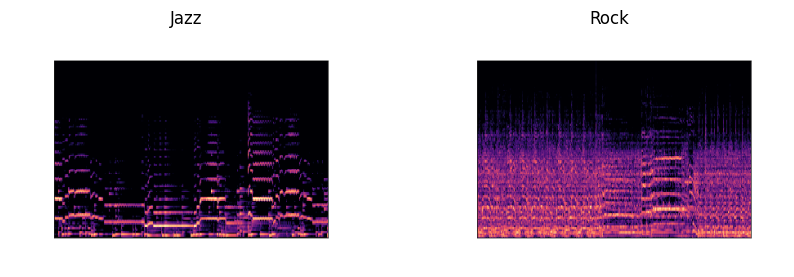

In [ ]:
# Update paths to use DATA_PATH variable
jazz_audio = mpimg.imread(f'{DATA_PATH}/images_original/jazz/jazz00004.png')
rock_audio = mpimg.imread(f'{DATA_PATH}/images_original/rock/rock00008.png')


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.imshow(jazz_audio) 
ax1.set_title('Jazz')
ax1.axis('off')

ax2.imshow(rock_audio)
ax2.set_title('Rock')
ax2.axis('off')

plt.show()

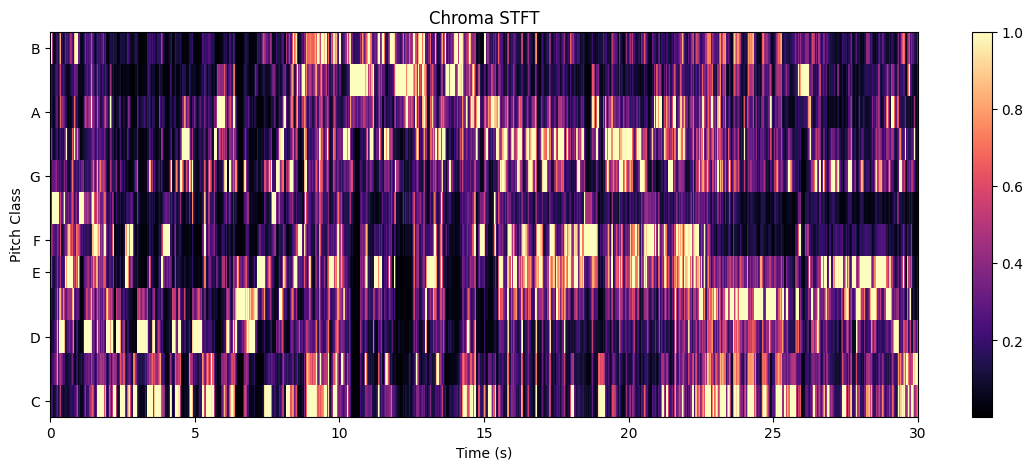

In [11]:
chroma_stft = librosa.feature.chroma_stft(y=audio, sr=sr)

plt.figure(figsize=(14, 5))
librosa.display.specshow(chroma_stft, x_axis='time', y_axis='chroma', sr=sr)
plt.colorbar()
plt.xlabel('Time (s)')
plt.ylabel('Pitch Class')
plt.title('Chroma STFT')
plt.show()

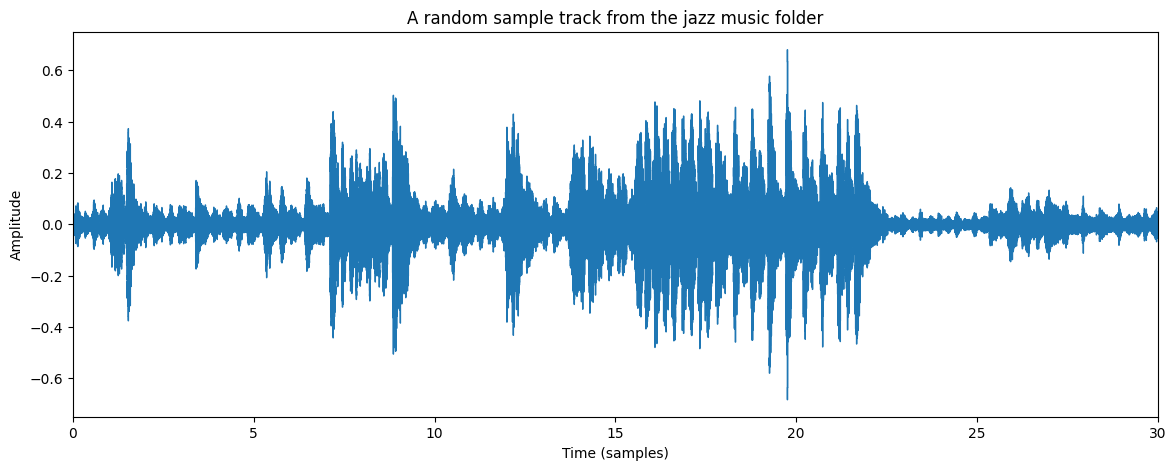

In [12]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(audio, sr=sr)
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.title('A random sample track from the jazz music folder')
plt.xlim([0,30])
plt.show()

Listed below are the audio features that are able to be seen in the CSV provided by the GTZAN Dataset:

1. Chroma STFT (Short-Time Fourier Transform): Measures the intensity of different pitches in a music track, providing a representation of the audio in terms of its harmonic content across 12 different pitch classes.

2. RMS (Root Mean Square) Mean: Indicates the average power or loudness of the audio signal.

3. Spectral Centroid Mean: Represents the "center of mass" of the spectrum, giving a sense of the brightness of a sound.

4. Spectral Bandwidth Mean: Measures the width of the band of light at half the peak maximum and effectively indicates the range of frequencies present in the sound.

5. Rolloff Mean: The frequency below which a specified percentage (typically 85% to 95%) of the total spectral energy lies, highlighting the shape of the audio spectrum.

6. Zero Crossing Rate Mean: The rate at which the signal changes signs, which can indicate the noisiness or the complexity of a sound.

7. Harmony Mean: Extracts the harmonic components of the audio, which are important for the perception of musical notes.

8. Perceptual Sharpness Mean: Measures the sharpness or brightness of the audio, which affects how listeners perceive the "edge" or clarity of a sound.

9. Tempo: The speed at which a piece of music is played, calculated in beats per minute (BPM).

10. MFCC (Mel Frequency Cepstral Coefficients) Mean: Describes the overall shape of the spectral envelope and is widely used in audio signal processing and speech recognition for timbre and speech clarity characterization.

In [ ]:
# Update path to use DATA_PATH variable
features_3_sec_path = f'{DATA_PATH}/features_3_sec.csv'
features_3_sec = pd.read_csv(features_3_sec_path)

features_3_sec.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [ ]:
# Update path to use DATA_PATH variable
features_30_sec_path = f'{DATA_PATH}/features_30_sec.csv'
features_30_sec = pd.read_csv(features_30_sec_path)

features_30_sec.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


**Lets understand which features are:**

**Categorical?**

These values classify the samples into sets of similar samples. Within categorical features are the values nominal, ordinal, ratio, or interval based? Among other things this helps us select the appropriate plots for visualization.

* Categorical: label and filename

**Numerical?**

Which features are numerical? These values change from sample to sample. Within numerical features are the values discrete, continuous, or timeseries based? Among other things this helps us select the appropriate plots for visualization.

* Numerical: all audio features from length to mfcc20_var

**Alphanumeric?**

Numerical, alphanumeric data within same feature. These are candidates for correcting.

* There are none.

**Errors? Typos?**

This is harder to review for a large dataset, however reviewing a few samples from a smaller dataset may just tell us outright, which features may require correcting.

* This dataset was handed to us complete.

# Processing the data

Our data seems very structured with very feature ready for analyis, but we can drop filename since it speeds up our notebook and eases the processing. 

In [14]:
features_3_sec = features_3_sec.drop('filename', axis = 1)

In [15]:
X = features_3_sec.iloc[:,:-1]
y = features_3_sec.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)


In [16]:
X = features_3_sec.drop(columns=['label','tempo'])
y = features_3_sec['label']

In [17]:
#LabelEncoder from Scikit-learn is utilized to transform each unique music genre into a specific integer.
labelencoder = LabelEncoder()

y_train = labelencoder.fit_transform(y_train)
y_test = labelencoder.transform(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Data models

## K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a simple, yet effective machine learning algorithm used primarily for classification, though it can also be used for regression. It classifies a new data point based on the majority vote of its 'k' nearest neighbors, with 'k' being a user-defined constant. KNN is a type of instance-based learning, or lazy learning, where the function is only approximated locally and all computation is deferred until classification. The simplicity of KNN makes it particularly easy to implement and understand, but it becomes significantly slower as the size of data increases.

In [18]:
# Define the parameter grid for the random search
param_grid = {
    'n_neighbors': randint(1, 15),  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Weight function
    'p': [1, 2]  # Power parameter for the Minkowski distance metric
}

# Create the KNN classifier
knn = KNeighborsClassifier()

# Perform the random search
random_search_knn = RandomizedSearchCV(
    knn, param_distributions=param_grid, n_iter=10, cv=5, random_state=42
)
random_search_knn.fit(X_train, y_train)

# Evaluate the KNN model with the best parameters on the test set
best_knn = random_search_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
test_accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Evaluate the KNN model on the training set
y_train_pred_knn = best_knn.predict(X_train)
train_accuracy_knn = accuracy_score(y_train, y_train_pred_knn)

print("Train KNN Accuracy:", train_accuracy_knn)
print("Test KNN Accuracy:", test_accuracy_knn)

Train KNN Accuracy: 0.9992492492492493
Test KNN Accuracy: 0.9324324324324325


## Artificial Neural Networks (ANN)

Artificial Neural Networks (ANN) are a cornerstone of modern machine learning, inspired by the biological processes of the human brain. ANNs consist of layers of interconnected nodes, or "neurons," each capable of performing simple computations. By processing inputs through multiple layers of these neurons, ANNs can model complex patterns and relationships within data. The adaptability and learning capability of ANNs make them particularly powerful for tackling large-scale and complex problems such as music genre classification.

In [19]:
# Define the model architecture
model = Sequential()
model.add(Dense(units=256, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.2))
model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=len(np.unique(y_train)), activation='softmax'))  # Adjusted to use np.unique for flexibility

# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_data=(X_test, y_test))

# Retrieve training and validation accuracy
train_accuracy = history.history['accuracy'][-1]  # Last epoch accuracy
val_accuracy = history.history['val_accuracy'][-1]  # Last epoch validation accuracy

# Predict on test set
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_pred_labels)

# Print accuracies
print('Training accuracy:', train_accuracy)
print('Validation accuracy:', val_accuracy)
print('Test accuracy:', test_accuracy)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-23 23:17:38.068500: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4005 - loss: 1.6461 - val_accuracy: 0.6797 - val_loss: 0.9283
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6817 - loss: 0.9327 - val_accuracy: 0.7497 - val_loss: 0.7206
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7460 - loss: 0.7567 - val_accuracy: 0.7973 - val_loss: 0.6090
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7742 - loss: 0.6531 - val_accuracy: 0.8123 - val_loss: 0.5457
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8080 - loss: 0.5544 - val_accuracy: 0.8198 - val_loss: 0.5347
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8285 - loss: 0.4942 - val_accuracy: 0.8504 - val_loss: 0.4505
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8503 - loss: 0.4382 - val_accuracy: 0.8654 - val_loss: 0.4180
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8670 - loss: 0.3784 - val_accuracy: 0.8629

## Long Short-term Memory (LSTM)

LSTM, or long short-term memory, is a type of recurrent neural network (RNN) designed to handle sequential data and learn long-term dependencies, solving the vanishing gradient problem that plagues traditional RNNs. It uses a special architecture with memory cells and three gates—forget, input, and output—to selectively store, forget, and output information over time. This makes LSTMs highly effective for tasks like natural language processing, speech recognition, and time series prediction.

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

y_train_cat = to_categorical(y_train_encoded)
y_test_cat = to_categorical(y_test_encoded)

X_train_reshaped = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_reshaped = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])


In [21]:
model = Sequential([
    # Input layer with batch normalization
    BatchNormalization(input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),

    # First Bidirectional LSTM layer
    Bidirectional(LSTM(256, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.3),

    # Second Bidirectional LSTM layer
    Bidirectional(LSTM(128, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),

    # Dense layers with increasing regularization
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),

    # Output layer
    Dense(10, activation='softmax')
])

# 2. Advanced Compilation Settings
optimizer = Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

# 3. Training with Early Stopping and Learning Rate Reduction
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# 4. Model Training
history = model.fit(
    X_train_reshaped,
    y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, lr_reducer],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.3098 - auc: 0.7332 - loss: 4.6646 - val_accuracy: 0.2702 - val_auc: 0.7730 - val_loss: 3.8898 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5356 - auc: 0.8928 - loss: 3.1750 - val_accuracy: 0.6229 - val_auc: 0.9401 - val_loss: 2.4782 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6240 - auc: 0.9258 - loss: 2.3825 - val_accuracy: 0.7392 - val_auc: 0.9685 - val_loss: 1.7220 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6671 - auc: 0.9390 - loss: 1.8760 - val_accuracy: 0.7611 - val_auc: 0.9739 - val_loss: 1.3433 - learning_rate: 0.0010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7009 - auc: 0.9506 - loss: 1.5140 - val_accuracy: 0.7742 - val_auc: 0.9758 - val_loss: 1.1327 - learning_rate: 0.0010
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7

In [32]:
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization, Bidirectional, Input
from tensorflow.keras.layers import Multiply, Permute, Reshape, Activation, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

# Define input shape
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])

# Model with Attention
inputs = Input(shape=input_shape)

# Initial normalization
x = BatchNormalization()(inputs)

# First Bidirectional LSTM with Attention
lstm1 = Bidirectional(LSTM(256, return_sequences=True))(x)
# Attention mechanism for first layer
attention1 = Dense(1, use_bias=True)(lstm1)
attention1 = Flatten()(attention1)
attention1 = Activation('softmax')(attention1)
attention1 = Reshape((1, attention1.shape[1]))(attention1)
attention_output1 = Multiply()([lstm1, attention1])
norm1 = BatchNormalization()(attention_output1)
drop1 = Dropout(0.3)(norm1)

# Second Bidirectional LSTM with Attention
lstm2 = Bidirectional(LSTM(128, return_sequences=True))(drop1)
# Attention mechanism for second layer
attention2 = Dense(1, use_bias=True)(lstm2)
attention2 = Flatten()(attention2)
attention2 = Activation('softmax')(attention2)
attention2 = Reshape((1, attention2.shape[1]))(attention2)
attention_output2 = Multiply()([lstm2, attention2])
norm2 = BatchNormalization()(attention_output2)
drop2 = Dropout(0.3)(norm2)

# Third Bidirectional LSTM
lstm3 = Bidirectional(LSTM(64, return_sequences=False))(drop2)
norm3 = BatchNormalization()(lstm3)
drop3 = Dropout(0.3)(norm3)

# Dense layers with regularization
dense1 = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(drop3)
norm4 = BatchNormalization()(dense1)
drop4 = Dropout(0.4)(norm4)

dense2 = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(drop4)
norm5 = BatchNormalization()(dense2)
drop5 = Dropout(0.4)(norm5)

# Output layer
outputs = Dense(10, activation='softmax')(drop5)

# Create model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Model summary
model.summary()

# Compile model
optimizer = Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', AUC(name='auc')]
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Model Training
history = model.fit(
    X_train_reshaped,
    y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, lr_reducer],
    verbose=1
)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1, 58)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 58)     │        232 │ input_layer_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 1, 512)    │    645,120 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1, 1)      │        513 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1)      │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 512)    │          0 │ bidirectional_2[… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 512)    │      2,048 │ multiply[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 1, 512)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 1, 256)    │    656,384 │ dropout_8[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1, 1)      │        257 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1)         │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1)         │          0 │ flatten_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1)      │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1, 256)    │          0 │ bidirectional_3[… │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 256)    │      1,024 │ multiply_1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 1, 256)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 128)       │    164,352 │ dropout_9[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,496,628 (5.71 MB)

 Trainable params: 1,494,336 (5.70 MB)

 Non-trainable params: 2,292 (8.95 KB)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.2381 - auc: 0.6655 - loss: 4.5299 - val_accuracy: 0.3408 - val_auc: 0.8144 - val_loss: 3.5676 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4602 - auc: 0.8635 - loss: 3.1140 - val_accuracy: 0.6248 - val_auc: 0.9367 - val_loss: 2.3666 - learning_rate: 0.0010
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5333 - auc: 0.9006 - loss: 2.4767 - val_accuracy: 0.6779 - val_auc: 0.9520 - val_loss: 1.8280 - learning_rate: 0.0010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6119 - auc: 0.9184 - loss: 2.0022 - val_accuracy: 0.7448 - val_auc: 0.9651 - val_loss: 1.4181 - learning_rate: 0.0010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6663 - auc: 0.9374 - loss: 1.6092 - val_accuracy: 0.7517 - val_auc: 0.9692 - val_loss: 1.1851 - learning_rate: 0.0010
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6971 - auc: 0

# Evaluate accuracy

/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


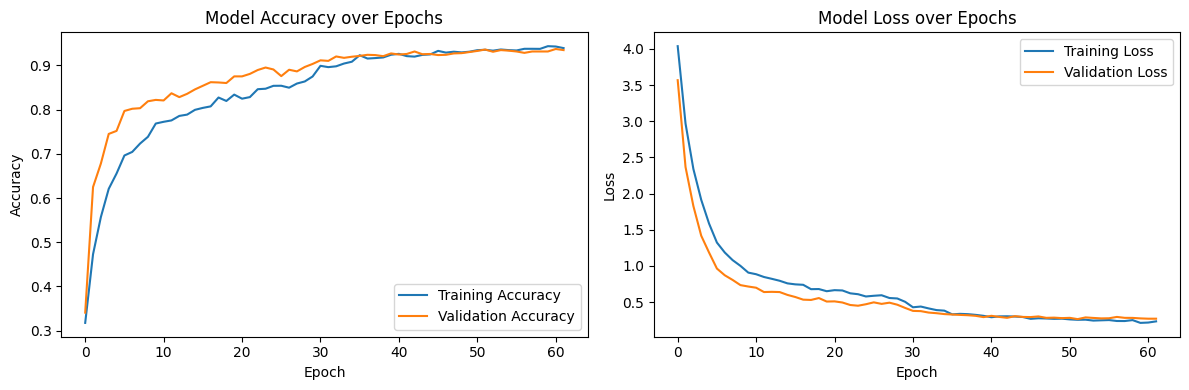


Classification Report:
              precision    recall  f1-score   support

       blues       0.91      0.93      0.92       208
   classical       0.95      0.97      0.96       203
     country       0.88      0.92      0.90       186
       disco       0.93      0.90      0.92       199
      hiphop       0.93      0.94      0.93       218
        jazz       0.90      0.95      0.93       192
       metal       0.95      0.97      0.96       204
         pop       0.95      0.97      0.96       180
      reggae       0.98      0.91      0.95       211
        rock       0.92      0.85      0.88       197

    accuracy                           0.93      1998
   macro avg       0.93      0.93      0.93      1998
weighted avg       0.93      0.93      0.93      1998


Detailed Metrics:
Accuracy: 0.9299
Precision: 0.9306
Recall: 0.9299
F1 Score: 0.9298


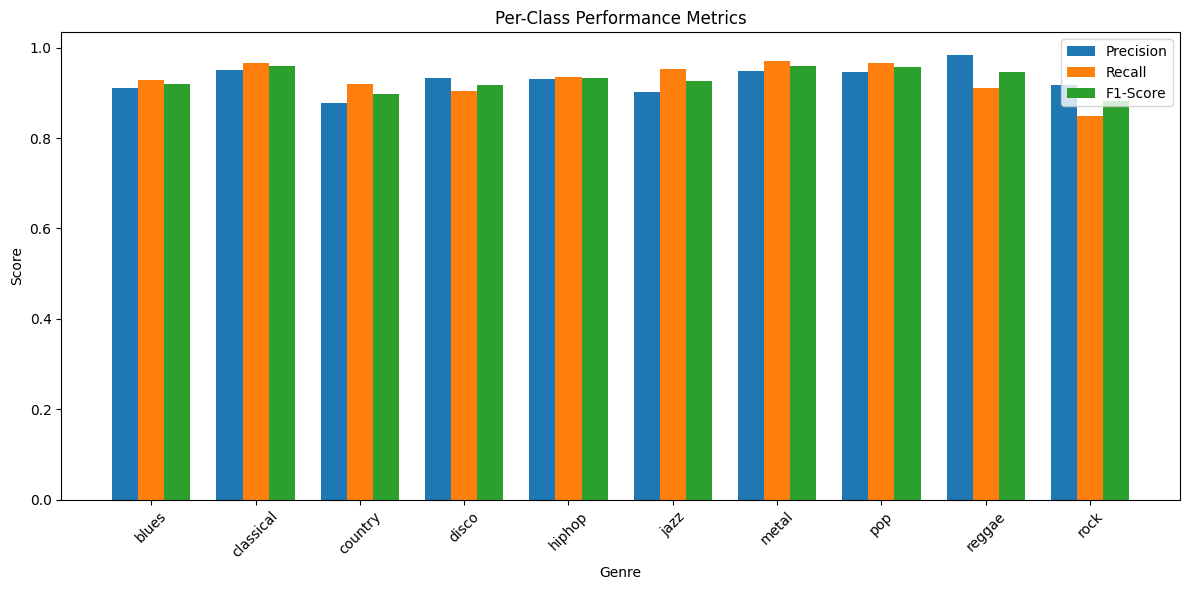

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support

# Get predictions
y_pred = model.predict(X_test_reshaped)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)

# 1. Plot Training History
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Print Classification Report
class_names = labelencoder.classes_  # Get original class names
print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=class_names))

# 4. Calculate and display various metrics
accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_classes, y_pred_classes, average='weighted')

print("\nDetailed Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# 6. Plot Per-Class Performance
plt.figure(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.25

precision_per_class = precision_recall_fscore_support(y_test_classes, y_pred_classes)[0]
recall_per_class = precision_recall_fscore_support(y_test_classes, y_pred_classes)[1]
f1_per_class = precision_recall_fscore_support(y_test_classes, y_pred_classes)[2]

plt.bar(x - width, precision_per_class, width, label='Precision')
plt.bar(x, recall_per_class, width, label='Recall')
plt.bar(x + width, f1_per_class, width, label='F1-Score')

plt.xlabel('Genre')
plt.ylabel('Score')
plt.title('Per-Class Performance Metrics')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
predictions = model.predict(X_test_reshaped)

predicted_labels = predictions.argmax(axis=1)
true_labels = y_test_encoded

#for i in range(10):  # Display the first 10 predictions
#    print(f"True label: {true_labels[i]}, Predicted label: {predicted_labels[i]}")

# Get the original genre names using label_encoder.inverse_transform()
predicted_genre_names = label_encoder.inverse_transform(predicted_labels)
true_genre_names = label_encoder.inverse_transform(true_labels)

for i in range(10):  # Display the first 10 predictions
    print(f"True genre: {true_genre_names[i]}, Predicted genre: {predicted_genre_names[i]}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
True genre: 4, Predicted genre: 4
True genre: 5, Predicted genre: 5
True genre: 0, Predicted genre: 0
True genre: 0, Predicted genre: 0
True genre: 6, Predicted genre: 3
True genre: 9, Predicted genre: 9
True genre: 7, Predicted genre: 7
True genre: 2, Predicted genre: 2
True genre: 2, Predicted genre: 2
True genre: 0, Predicted genre: 0


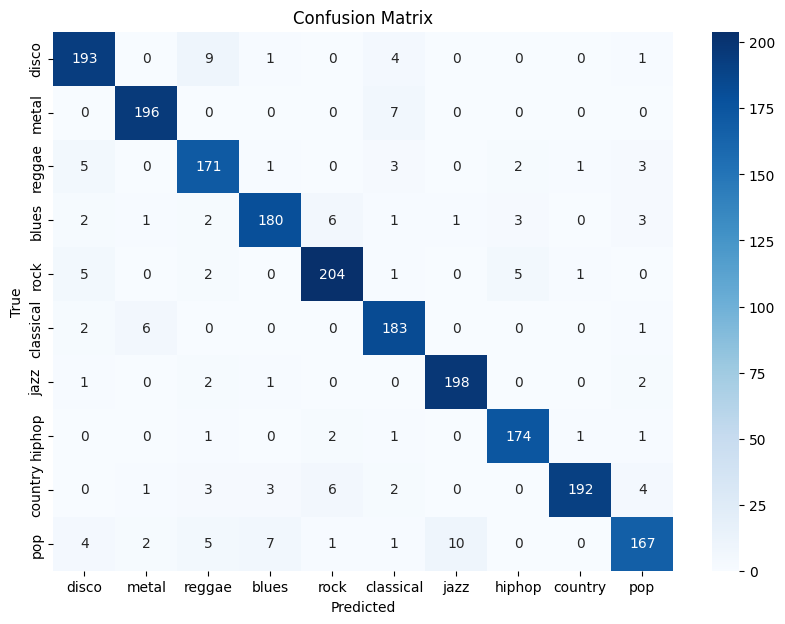

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Update path to use DATA_PATH variable
genres_path = f'{DATA_PATH}/genres_original'

genres = os.listdir(genres_path)

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=genres, yticklabels=genres)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [37]:
predictions = model.predict(X_test_reshaped)

predicted_labels = predictions.argmax(axis=1)
true_labels = y_test_encoded


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


# 💾 Download Trained Model

Save and download your trained model to use it later for predictions!

In [ ]:
# Save the model
model.save('music_genre_classifier_model.h5')
print("✅ Model saved as 'music_genre_classifier_model.h5'")

# Save the label encoder
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✅ Label encoder saved as 'label_encoder.pkl'")

# Save model summary to text file
with open('model_summary.txt', 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
print("✅ Model summary saved as 'model_summary.txt'")

In [ ]:
# Download the model files to your local machine
from google.colab import files

print("📥 Downloading model files...")
print("=" * 50)

# Download model
files.download('music_genre_classifier_model.h5')
print("✅ Downloaded: music_genre_classifier_model.h5")

# Download label encoder
files.download('label_encoder.pkl')
print("✅ Downloaded: label_encoder.pkl")

# Download model summary
files.download('model_summary.txt')
print("✅ Downloaded: model_summary.txt")

print("=" * 50)
print("✅ All files downloaded successfully!")
print("\nYou can now use these files to make predictions on new audio files.")